# Projeto CardioIA - Visão Computacional (Fase 4)
## Parte 1: Pré-processamento e Organização das Imagens
## Parte 2: Classificação de Imagens Médicas com CNN e Transfer Learning Otimizado

Importação das Bibliotecas

In [3]:
import os
import io
import random
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import DenseNet121
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix

# Garante reprodutibilidade dos pesos iniciais
np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow Versão:", tf.__version__)
print("Ambiente configurado com sucesso.")

TensorFlow Versão: 2.21.0
Ambiente configurado com sucesso.


In [10]:
# 1. Captura o diretório atual de execução de forma limpa
try:
    BASE_DIR_ATUAL = os.path.dirname(os.path.abspath(__file__))
except NameError:
    BASE_DIR_ATUAL = os.getcwd()

# 2. Evita duplicação conferindo se "fase-4-visao-computacional" já está no caminho atual
if "fase-4-visao-computacional" in BASE_DIR_ATUAL:
    # Se já está na pasta da fase 4, vai direto para a pasta do dataset
    BASE_DIR = os.path.join(BASE_DIR_ATUAL, "dataset_estruturado")
else:
    # Se está na raiz do projeto (cardio-ia), monta o caminho completo padrão
    BASE_DIR = os.path.join(BASE_DIR_ATUAL, "fase-4-visao-computacional", "dataset_estruturado")

print(f"-> Caminho dinâmico do Dataset corrigido e mapeado em:\n   {BASE_DIR}\n")

# Datagen do Zero (Apenas normalização de escala para a CNN própria)
train_datagen_zero = ImageDataGenerator(rescale=1./255, rotation_range=15, width_shift_range=0.1, height_shift_range=0.1, fill_mode='nearest')
val_test_datagen_zero = ImageDataGenerator(rescale=1./255)

# Datagen para DenseNet (Usa a função de pré-processamento nativa da arquitetura)
train_datagen_dense = ImageDataGenerator(preprocessing_function=tf.keras.applications.densenet.preprocess_input, rotation_range=15, width_shift_range=0.1, height_shift_range=0.1, fill_mode='nearest')
val_test_datagen_dense = ImageDataGenerator(preprocessing_function=tf.keras.applications.densenet.preprocess_input)

# Geradores de Treino, Validação e Teste (CNN do Zero)
train_gen_zero = train_datagen_zero.flow_from_directory(os.path.join(BASE_DIR, 'train'), target_size=(256, 256), batch_size=16, class_mode='categorical', shuffle=True)
val_gen_zero = val_test_datagen_zero.flow_from_directory(os.path.join(BASE_DIR, 'validation'), target_size=(256, 256), batch_size=16, class_mode='categorical', shuffle=False)
test_gen_zero = val_test_datagen_zero.flow_from_directory(os.path.join(BASE_DIR, 'test'), target_size=(256, 256), batch_size=16, class_mode='categorical', shuffle=False)

# Geradores de Treino, Validação e Teste (DenseNet121)
train_gen_dense = train_datagen_dense.flow_from_directory(os.path.join(BASE_DIR, 'train'), target_size=(256, 256), batch_size=16, class_mode='categorical', shuffle=True)
val_gen_dense = val_test_datagen_dense.flow_from_directory(os.path.join(BASE_DIR, 'validation'), target_size=(256, 256), batch_size=16, class_mode='categorical', shuffle=False)
test_gen_dense = val_test_datagen_dense.flow_from_directory(os.path.join(BASE_DIR, 'test'), target_size=(256, 256), batch_size=16, class_mode='categorical', shuffle=False)

-> Caminho dinâmico do Dataset corrigido e mapeado em:
   c:\Users\gfbugatti\OneDrive - Viasat, Inc\Documentos\Estudos\cardio ia\cardio-ia\fase-4-visao-computacional\dataset_estruturado

Found 2757 images belonging to 3 classes.
Found 561 images belonging to 3 classes.
Found 564 images belonging to 3 classes.
Found 2757 images belonging to 3 classes.
Found 561 images belonging to 3 classes.
Found 564 images belonging to 3 classes.


Carregamento dos Datasets via TensorFlow API

In [11]:
# Cálculo dos pesos baseado no gerador do zero (a distribuição é a mesma)
y_train = train_gen_zero.classes
classes_unicas = np.unique(y_train)
pesos_calculados = compute_class_weight(class_weight='balanced', classes=classes_unicas, y=y_train)
class_weights_dict = dict(zip(classes_unicas, pesos_calculados))

def categorical_focal_loss(gamma=2.0, alpha=0.25):
    def focal_loss(y_true, y_pred):
        y_pred = tf.clip_by_value(y_pred, tf.keras.backend.epsilon(), 1.0 - tf.keras.backend.epsilon())
        cross_entropy = -y_true * tf.math.log(y_pred)
        loss = alpha * tf.math.pow(1.0 - y_pred, gamma) * cross_entropy
        return tf.reduce_mean(tf.reduce_sum(loss, axis=-1))
    return focal_loss

# Multiplicadores para forçar a sensibilidade clínica no teste
multiplicadores_medicos = np.array([1.5, 1.3, 1.0]) # [Cardiomegalia, Infiltrado, Saudavel]
nomes_classes = list(train_gen_zero.class_indices.keys())

Inspeção Visual das Imagens

Visualizando imagens tratadas para a CNN do Zero (Escala [0, 1]):


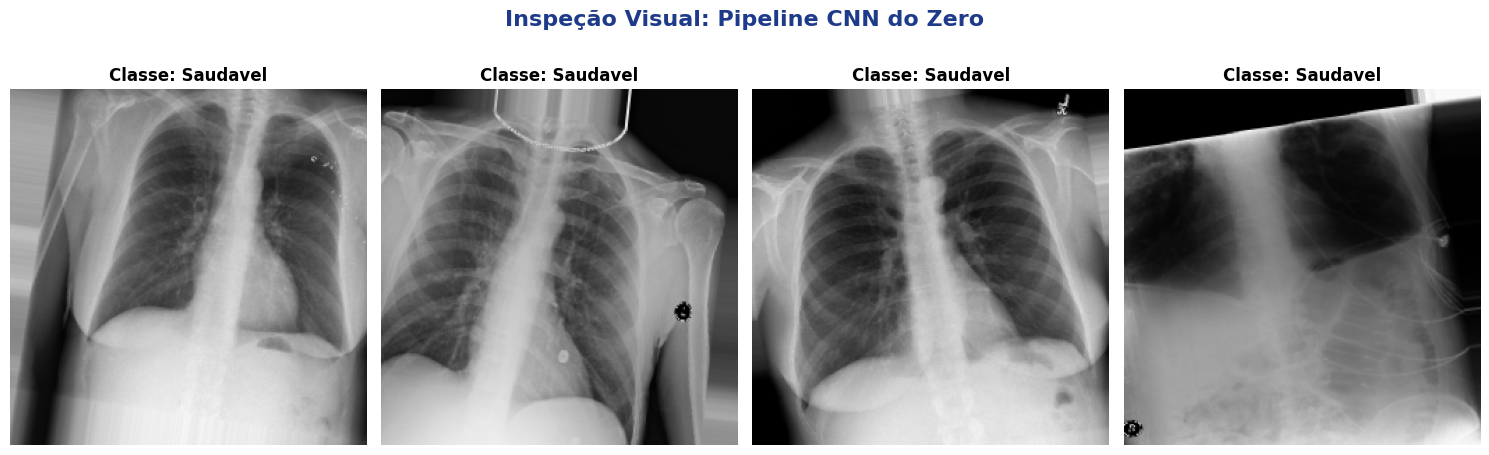


Visualizando imagens tratadas para a DenseNet121 (Normalização Nativa):


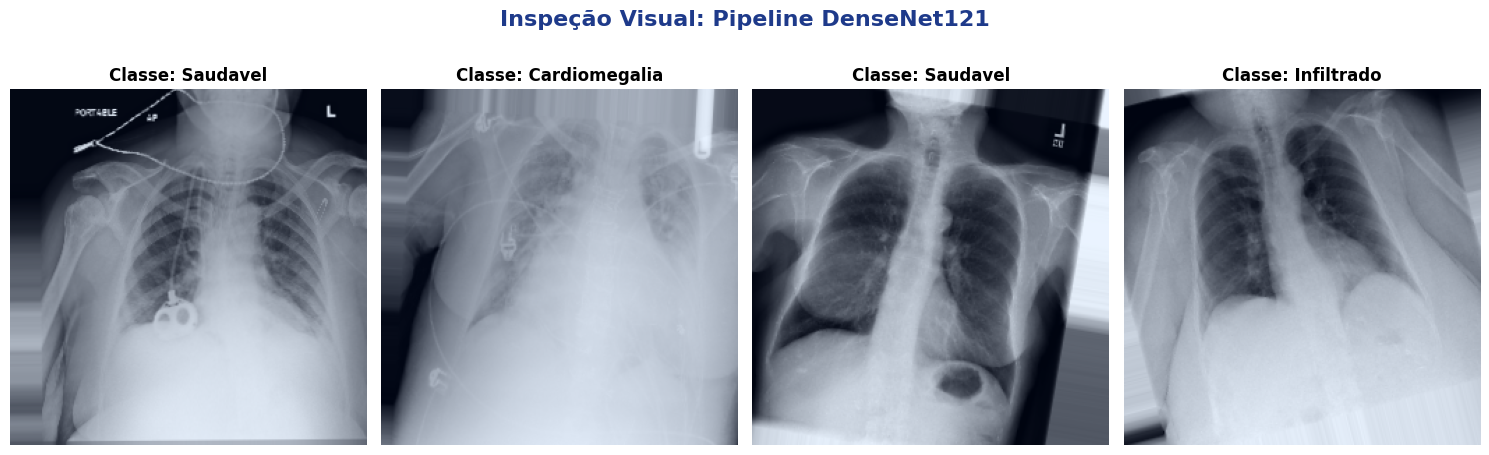

In [12]:
def inspecionar_gerador(generator, titulo="Amostras do Dataset"):
    """
    Extrai um lote do gerador de dados e exibe as primeiras 4 imagens 
    com suas respectivas classes clínicas mapeadas.
    """
    # Pega o primeiro lote (batch) de imagens e labels
    imagens, labels = next(generator)
    
    # Inverte o dicionário de classes para descobrir o nome a partir do índice
    indices_classes = {v: k for k, v in generator.class_indices.items()}
    
    plt.figure(figsize=(15, 5))
    plt.suptitle(titulo, fontsize=16, weight='bold', color='#1E3A8A')
    
    # Exibe as 4 primeiras imagens do lote
    for i in range(4):
        plt.subplot(1, 4, i + 1)
        
        # Desfaz a normalização apenas para exibição visual caso a imagem esteja fora de [0,1]
        img_exibicao = imagens[i]
        if img_exibicao.min() < 0: # Se for o gerador da DenseNet (valores negativos)
            # Redimensiona para o intervalo [0, 1] para o matplotlib não estourar aviso
            img_exibicao = (img_exibicao - img_exibicao.min()) / (img_exibicao.max() - img_exibicao.min())
            
        plt.imshow(img_exibicao)
        
        # Descobre o nome da classe pelo vetor One-Hot Encoding
        classe_idx = np.argmax(labels[i])
        classe_nome = indices_classes[classe_idx]
        
        plt.title(f"Classe: {classe_nome}", fontsize=12, weight='semibold')
        plt.axis('off')
        
    plt.tight_layout()
    plt.show()

# --- EXECUÇÃO DA INSPEÇÃO ---

print("Visualizando imagens tratadas para a CNN do Zero (Escala [0, 1]):")
inspecionar_gerador(train_gen_zero, titulo="Inspeção Visual: Pipeline CNN do Zero")

print("\nVisualizando imagens tratadas para a DenseNet121 (Normalização Nativa):")
inspecionar_gerador(train_gen_dense, titulo="Inspeção Visual: Pipeline DenseNet121")

## PARTE 2 - Classificação de Imagens Médicas com CNN
### Abordagem 1: Arquitetura CNN Desenvolvida do Zero (Baseline)

In [13]:
model_zero = models.Sequential([
    layers.Input(shape=(256, 256, 3)),
    
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(3, activation='softmax')
])

model_zero.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=categorical_focal_loss(gamma=2.0, alpha=0.25),
    metrics=['accuracy']
)

Treinamento da CNN do Zero

In [14]:
callbacks_zero = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-6)
]

print("Treinando CNN Desenvolvida do Zero...")
history_zero = model_zero.fit(
    train_gen_zero,
    epochs=30,
    validation_data=val_gen_zero,
    class_weight=class_weights_dict,
    callbacks=callbacks_zero
)

Treinando CNN Desenvolvida do Zero...
Epoch 1/30
173/173 ━━━━━━━━━━━━━━━━━━━━ 280s 2s/step - accuracy: 0.6362 - loss: 0.3289 - val_accuracy: 0.2121 - val_loss: 1.3746 - learning_rate: 1.0000e-04
Epoch 2/30
173/173 ━━━━━━━━━━━━━━━━━━━━ 284s 2s/step - accuracy: 0.6804 - loss: 0.0996 - val_accuracy: 0.7308 - val_loss: 0.0820 - learning_rate: 1.0000e-04
Epoch 3/30
173/173 ━━━━━━━━━━━━━━━━━━━━ 237s 1s/step - accuracy: 0.6942 - loss: 0.0966 - val_accuracy: 0.7166 - val_loss: 0.0714 - learning_rate: 1.0000e-04
Epoch 4/30
173/173 ━━━━━━━━━━━━━━━━━━━━ 242s 1s/step - accuracy: 0.6913 - loss: 0.0934 - val_accuracy: 0.7308 - val_loss: 0.0671 - learning_rate: 1.0000e-04
Epoch 5/30
173/173 ━━━━━━━━━━━━━━━━━━━━ 258s 1s/step - accuracy: 0.6899 - loss: 0.0939 - val_accuracy: 0.7326 - val_loss: 0.0647 - learning_rate: 1.0000e-04
Epoch 6/30
173/173 ━━━━━━━━━━━━━━━━━━━━ 238s 1s/step - accuracy: 0.6950 - loss: 0.0888 - val_accuracy: 0.7255 - val_loss: 0.0786 - learning_rate: 1.0000e-04
Epoch 7/30
173/173 ━

Métricas e Matriz de Confusão

36/36 ━━━━━━━━━━━━━━━━━━━━ 21s 551ms/step

=== RELATÓRIO FINAL: CNN DESENVOLVIDA DO ZERO ===
               precision    recall  f1-score   support

Cardiomegalia       0.23      0.20      0.21        30
   Infiltrado       0.31      0.10      0.15       120
     Saudavel       0.77      0.93      0.84       414

     accuracy                           0.71       564
    macro avg       0.44      0.41      0.40       564
 weighted avg       0.64      0.71      0.66       564



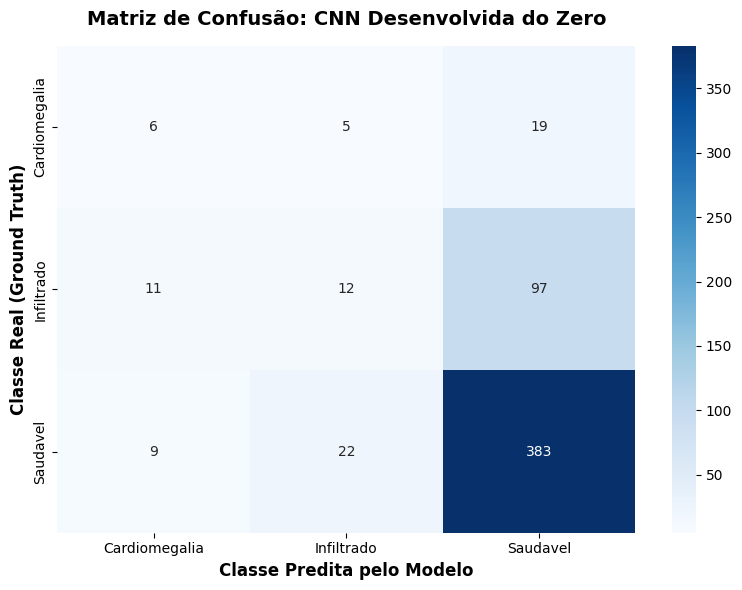

In [ ]:
# 1. Executa a inferência e aplica os multiplicadores clínicos
preds_raw_zero = model_zero.predict(test_gen_zero)
preds_ajustadas_zero = preds_raw_zero * multiplicadores_medicos
y_pred_zero = np.argmax(preds_ajustadas_zero, axis=1)
y_true_zero = test_gen_zero.classes

# 2. Imprime o relatório textual
print("\n=== RELATÓRIO FINAL: CNN DESENVOLVIDA DO ZERO ===")
print(classification_report(y_true_zero, y_pred_zero, target_names=nomes_classes))

# 3. Calcula a matriz de confusão numérica
cm_zero = confusion_matrix(y_true_zero, y_pred_zero)

# 4. Renderiza o gráfico da Matriz de Confusão
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_zero, 
    annot=True,          # Coloca os números dentro dos quadrados
    fmt='d',             # Formata os números como inteiros
    cmap='Blues',        # Degradê de azul
    xticklabels=nomes_classes, 
    yticklabels=nomes_classes,
    cbar=True
)

plt.title('Matriz de Confusão: CNN Desenvolvida do Zero', fontsize=14, weight='bold', pad=15)
plt.ylabel('Classe Real (Ground Truth)', fontsize=12, weight='semibold')
plt.xlabel('Classe Predita pelo Modelo', fontsize=12, weight='semibold')
plt.tight_layout()
plt.show()

### Abordagem 2: Transfer Learning de Alta Performance com ResNet50V2 e Fine-Tuning Corrigido

In [16]:
base_model = DenseNet121(weights='imagenet', include_top=False, input_shape=(256, 256, 3))
base_model.trainable = False  # Congela a base pré-treinada

inputs = layers.Input(shape=(256, 256, 3))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.4)(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(3, activation='softmax')(x)

model_dense = models.Model(inputs, outputs)

model_dense.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=categorical_focal_loss(gamma=2.0, alpha=0.25),
    metrics=['accuracy']
)

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


In [17]:
callbacks_dense = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-6)
]

print("Treinando Transfer Learning com DenseNet121...")
history_dense = model_dense.fit(
    train_gen_dense,
    epochs=30,
    validation_data=val_gen_dense,
    class_weight=class_weights_dict,
    callbacks=callbacks_dense
)

Treinando Transfer Learning com DenseNet121...
Epoch 1/30
173/173 ━━━━━━━━━━━━━━━━━━━━ 356s 2s/step - accuracy: 0.4534 - loss: 0.1983 - val_accuracy: 0.6613 - val_loss: 0.0900 - learning_rate: 1.0000e-04
Epoch 2/30
173/173 ━━━━━━━━━━━━━━━━━━━━ 293s 2s/step - accuracy: 0.5629 - loss: 0.1512 - val_accuracy: 0.7112 - val_loss: 0.0768 - learning_rate: 1.0000e-04
Epoch 3/30
173/173 ━━━━━━━━━━━━━━━━━━━━ 304s 2s/step - accuracy: 0.6050 - loss: 0.1385 - val_accuracy: 0.7273 - val_loss: 0.0741 - learning_rate: 1.0000e-04
Epoch 4/30
173/173 ━━━━━━━━━━━━━━━━━━━━ 263s 1s/step - accuracy: 0.5978 - loss: 0.1322 - val_accuracy: 0.7273 - val_loss: 0.0705 - learning_rate: 1.0000e-04
Epoch 5/30
173/173 ━━━━━━━━━━━━━━━━━━━━ 239s 1s/step - accuracy: 0.6115 - loss: 0.1273 - val_accuracy: 0.7219 - val_loss: 0.0677 - learning_rate: 1.0000e-04
Epoch 6/30
173/173 ━━━━━━━━━━━━━━━━━━━━ 348s 2s/step - accuracy: 0.6217 - loss: 0.1186 - val_accuracy: 0.7415 - val_loss: 0.0651 - learning_rate: 1.0000e-04
Epoch 7/30


36/36 ━━━━━━━━━━━━━━━━━━━━ 49s 1s/step

=== RELATÓRIO FINAL: TRANSFER LEARNING (DENSENET121) ===
               precision    recall  f1-score   support

Cardiomegalia       0.29      0.47      0.36        30
   Infiltrado       0.34      0.38      0.36       120
     Saudavel       0.80      0.73      0.77       414

     accuracy                           0.65       564
    macro avg       0.48      0.53      0.49       564
 weighted avg       0.67      0.65      0.66       564



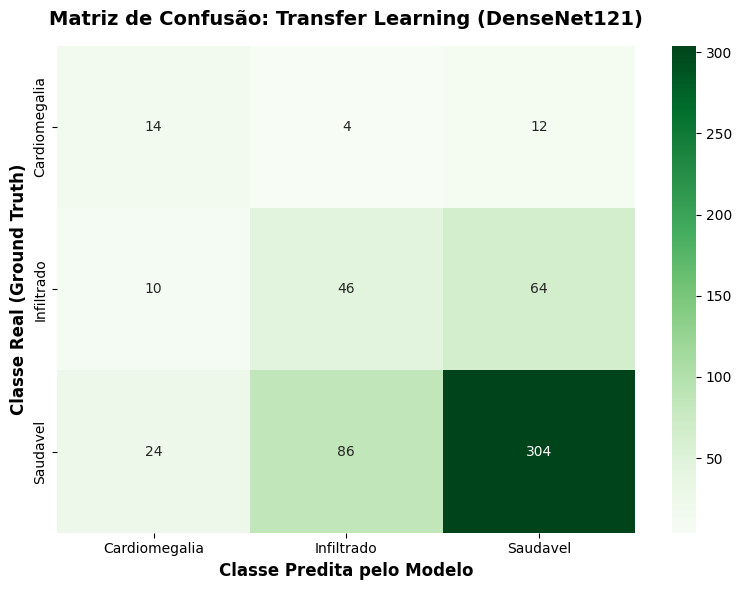

In [18]:
# 1. Executa a inferência no conjunto de teste oculto com a DenseNet121
preds_raw_dense = model_dense.predict(test_gen_dense)

# 2. Aplica os multiplicadores clínicos para salvar as classes patológicas
preds_ajustadas_dense = preds_raw_dense * multiplicadores_medicos
y_pred_dense = np.argmax(preds_ajustadas_dense, axis=1)
y_true_dense = test_gen_dense.classes

# 3. Imprime o relatório textual com Precision, Recall e F1-Score
print("\n=== RELATÓRIO FINAL: TRANSFER LEARNING (DENSENET121) ===")
print(classification_report(y_true_dense, y_pred_dense, target_names=nomes_classes))

# 4. Calcula a matriz de confusão numérica
cm_dense = confusion_matrix(y_true_dense, y_pred_dense)

# 5. Renderiza o gráfico da Matriz de Confusão em tons de Verde
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_dense, 
    annot=True,          # Desenha os números de exames dentro de cada quadrante
    fmt='d',             # Garante a formatação como número inteiro (ex: 25)
    cmap='Greens',       # Degradê em verde para combinar com o layout do app
    xticklabels=nomes_classes, 
    yticklabels=nomes_classes,
    cbar=True
)

plt.title('Matriz de Confusão: Transfer Learning (DenseNet121)', fontsize=14, weight='bold', pad=15)
plt.ylabel('Classe Real (Ground Truth)', fontsize=12, weight='semibold')
plt.xlabel('Classe Predita pelo Modelo', fontsize=12, weight='semibold')
plt.tight_layout()
plt.show()

Exportação do Melhor Modelo para a Interface Flask

In [20]:
OUTPUT_MODEL_PATH = "fase-4-visao-computacional\parte1\melhor_modelo_cardioia.h5"

# Salvando o modelo da DenseNet121 que possui maior robustez de extração de features
model_dense.save(OUTPUT_MODEL_PATH)
print(f"Sucesso! Modelo exportado com calibragem para: {OUTPUT_MODEL_PATH}")

Sucesso! Modelo exportado com calibragem para: fase-4-visao-computacional\parte1\melhor_modelo_cardioia.h5
